# Week 6 — Multiple Time Series & VAR Models

When variables interact — GDP growth affects unemployment which affects consumption — we need multivariate models. The Vector Autoregression (VAR) is the workhorse.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Edinburgh palette
UOE_RED   = '#7A2318'
UOE_GOLD  = '#B8860B'
UOE_BLUE  = '#2a78d6'
UOE_GREY  = '#52514e'
COLOURS   = [UOE_RED, UOE_BLUE, UOE_GOLD, '#2ca02c', '#9467bd', '#e377c2']

mpl.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.prop_cycle': mpl.cycler(color=COLOURS),
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 12, 'axes.titlesize': 14,
    'font.size': 11, 'legend.fontsize': 10,
    'lines.linewidth': 2,
})
print("Plotting style set ✓")


Plotting style set ✓


## 6.1 The VAR(p) Model

For a vector $\mathbf{y}_t = (y_{1t}, y_{2t}, \dots, y_{nt})'$:

$$\mathbf{y}_t = \mathbf{c} + \mathbf{A}_1 \mathbf{y}_{t-1} + \cdots + \mathbf{A}_p \mathbf{y}_{t-p} + \mathbf{u}_t$$

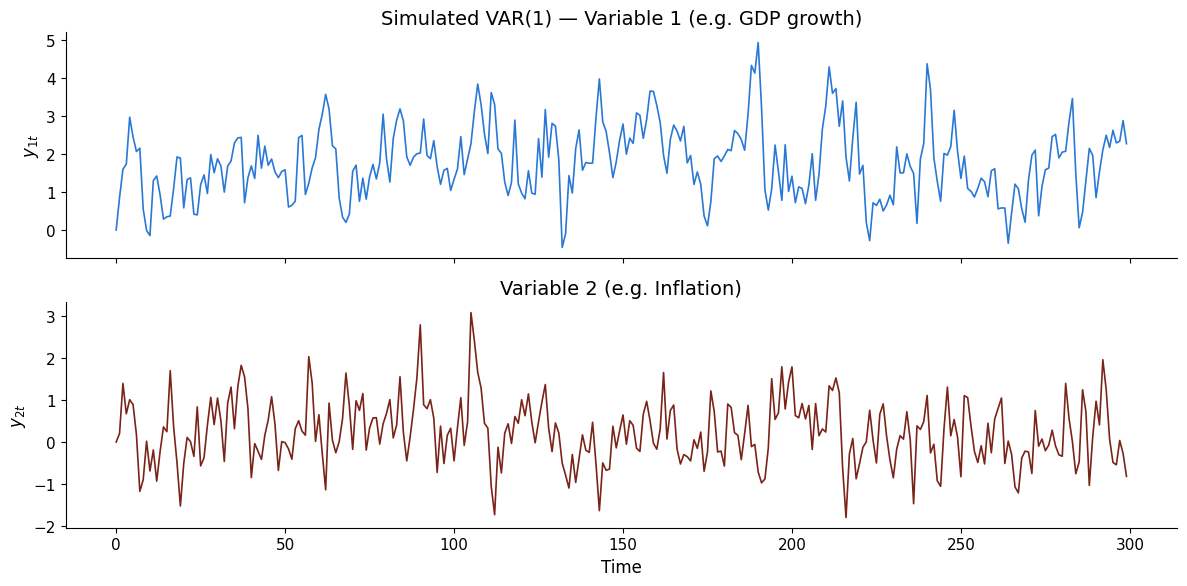

In [2]:
# Simulate a bivariate VAR(1)
np.random.seed(42)
T = 300
A = np.array([[0.7, 0.2],
              [-0.1, 0.5]])
c = np.array([0.5, 0.3])

Y = np.zeros((T, 2))
for t in range(1, T):
    Y[t] = c + A @ Y[t-1] + np.random.multivariate_normal([0, 0], 0.5*np.eye(2))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(Y[:, 0], color=UOE_BLUE, lw=1.2)
ax1.set_ylabel('$y_{1t}$')
ax1.set_title('Simulated VAR(1) — Variable 1 (e.g. GDP growth)')

ax2.plot(Y[:, 1], color=UOE_RED, lw=1.2)
ax2.set_ylabel('$y_{2t}$')
ax2.set_title('Variable 2 (e.g. Inflation)')
ax2.set_xlabel('Time')

plt.tight_layout()
plt.show()


## 6.2 Estimating a VAR with `statsmodels`

In [3]:
from statsmodels.tsa.api import VAR
import pandas as pd

df = pd.DataFrame(Y, columns=['GDP_growth', 'Inflation'])
model = VAR(df)

# Select lag order
print("Lag order selection:")
print(model.select_order(maxlags=8).summary())


Lag order selection:
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0     -0.6514     -0.6262      0.5213     -0.6413
1     -1.459*     -1.384*     0.2324*     -1.429*
2      -1.444      -1.318      0.2360      -1.393
3      -1.433      -1.257      0.2386      -1.362
4      -1.420      -1.193      0.2417      -1.329
5      -1.410      -1.133      0.2443      -1.299
6      -1.395      -1.068      0.2478      -1.264
7      -1.374     -0.9961      0.2532      -1.222
8      -1.371     -0.9431      0.2539      -1.200
-------------------------------------------------


In [4]:
# Fit VAR(1)
result = model.fit(maxlags=1)
print(result.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 10, Aug, 2026
Time:                     08:28:57
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -1.39437
Nobs:                     299.000    HQIC:                  -1.43891
Log likelihood:          -622.966    FPE:                   0.230242
AIC:                     -1.46863    Det(Omega_mle):        0.225690
--------------------------------------------------------------------
Results for equation GDP_growth
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 0.585999         0.085762            6.833           0.000
L1.GDP_growth         0.649079         0.042581           15.243           0.000
L1.Inflation          0.189202         0.052933        

## 6.3 Impulse Response Functions

IRFs trace the effect of a one-unit shock in one variable on all variables over time.

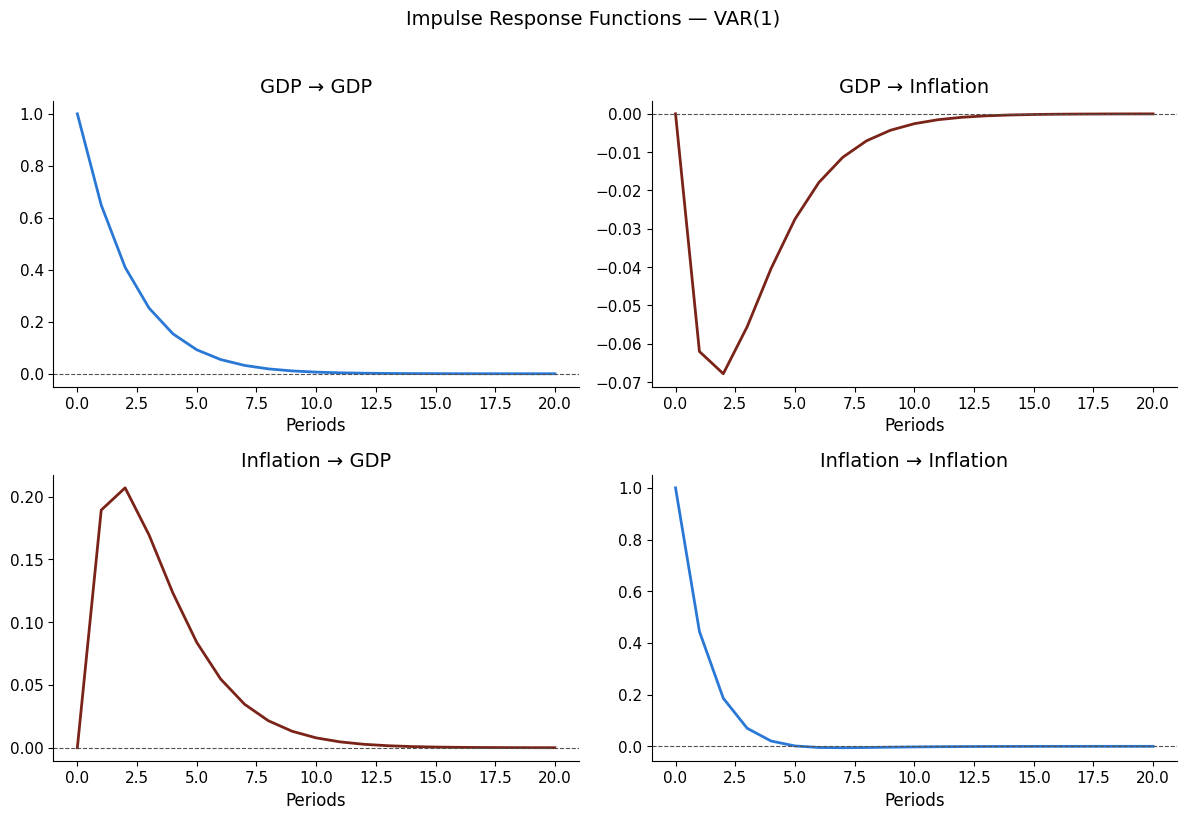

In [5]:
irf = result.irf(periods=20)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
titles = [['GDP → GDP', 'GDP → Inflation'],
          ['Inflation → GDP', 'Inflation → Inflation']]
colours = [[UOE_BLUE, UOE_RED], [UOE_RED, UOE_BLUE]]

for i in range(2):
    for j in range(2):
        ax = axes[i, j]
        resp = irf.irfs[:, j, i]
        lower = irf.ci[:, j, i, 0] if hasattr(irf, 'ci') else resp - 0.1
        upper = irf.ci[:, j, i, 1] if hasattr(irf, 'ci') else resp + 0.1
        ax.plot(resp, color=colours[i][j], lw=2)
        ax.axhline(0, ls='--', color=UOE_GREY, lw=0.8)
        ax.set_title(titles[i][j])
        ax.set_xlabel('Periods')

plt.suptitle('Impulse Response Functions — VAR(1)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 6.4 Granger Causality

Variable $x$ Granger-causes $y$ if past values of $x$ help predict $y$ beyond $y$'s own past.

In [6]:
from statsmodels.tsa.stattools import grangercausalitytests

print("Does Inflation Granger-cause GDP growth?")
gc1 = grangercausalitytests(df[['GDP_growth', 'Inflation']], maxlag=4, verbose=True)


Does Inflation Granger-cause GDP growth?

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=12.7761 , p=0.0004  , df_denom=296, df_num=1
ssr based chi2 test:   chi2=12.9056 , p=0.0003  , df=1
likelihood ratio test: chi2=12.6348 , p=0.0004  , df=1
parameter F test:         F=12.7761 , p=0.0004  , df_denom=296, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=5.9354  , p=0.0030  , df_denom=293, df_num=2
ssr based chi2 test:   chi2=12.0733 , p=0.0024  , df=2
likelihood ratio test: chi2=11.8352 , p=0.0027  , df=2
parameter F test:         F=5.9354  , p=0.0030  , df_denom=293, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=4.1228  , p=0.0069  , df_denom=290, df_num=3
ssr based chi2 test:   chi2=12.6669 , p=0.0054  , df=3
likelihood ratio test: chi2=12.4042 , p=0.0061  , df=3
parameter F test:         F=4.1228  , p=0.0069  , df_denom=290, df_num=3

Granger Causality
number of lags (no zero) 4
ssr bas

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


## 6.5 VAR Forecast

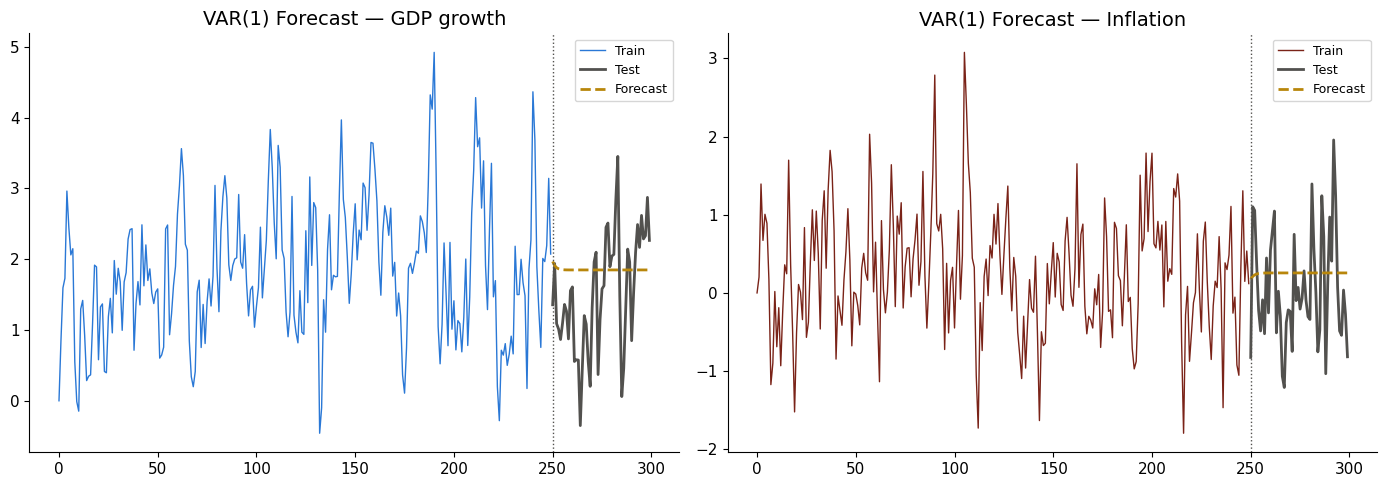

In [7]:
# Forecast
train_df = df.iloc[:250]
test_df = df.iloc[250:]
var_fit = VAR(train_df).fit(maxlags=1)
fc = var_fit.forecast(train_df.values[-1:], steps=50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, col_idx, name, colour in [(ax1, 0, 'GDP growth', UOE_BLUE),
                                    (ax2, 1, 'Inflation', UOE_RED)]:
    ax.plot(range(250), train_df.iloc[:, col_idx], color=colour, lw=1, label='Train')
    ax.plot(range(250, 300), test_df.iloc[:, col_idx], color=UOE_GREY, lw=2, label='Test')
    ax.plot(range(250, 300), fc[:, col_idx], '--', color=UOE_GOLD, lw=2, label='Forecast')
    ax.axvline(250, ls=':', color=UOE_GREY, lw=1)
    ax.set_title(f'VAR(1) Forecast — {name}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## Exercises

<details><summary>Exercise 1: Add a third variable (unemployment) and estimate a VAR(2).</summary>

```python
A3 = np.array([[0.6, 0.1, -0.05],
               [-0.1, 0.5, 0.1],
               [0.05, -0.15, 0.7]])
Y3 = np.zeros((300, 3))
for t in range(1, 300):
    Y3[t] = A3 @ Y3[t-1] + np.random.multivariate_normal([0,0,0], 0.3*np.eye(3))
df3 = pd.DataFrame(Y3, columns=['GDP','Inflation','Unemployment'])
VAR(df3).fit(maxlags=2).summary()
```
</details>